### 1. Libraries importing

In [4]:
import numpy as np
#import cupy as cp
import time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

### 2. Input values generation

In [55]:
def generate_matrixes(size, dtype=np.float32):

    size_m, size_k, size_n = size

    A = np.random.rand(size_m, size_k).astype(dtype)
    B = np.random.rand(size_k, size_n).astype(dtype)

    return A, B

### 3. Multiply functions

In [74]:
def matmul_cpu(A, B):
    size_m, size_k = A.shape
    size_k, size_n = B.shape
    C = np.zeros((size_m, size_n), dtype=A.dtype)

    for i in range(size_m):
        for j in range(size_n):
            for k in range(size_k):
                C[i, j] += A[i, k] * B[k, j]
    return C

def matmul_numpy(A, B):
    return A @ B

def matmul_gpu(A, B):
    A_gpu = cp.asarray(A)
    B_gpu = cp.asarray(B)

    C_gpu = A_gpu @ B_gpu

    C_cpu = cp.asnumpy(C_gpu)

    return C_cpu

### 4. Correctness function

In [57]:
def check_correctness(result_cpu, result_gpu, rtol=1e-5, atol=1e-8):
    return np.allclose(result_cpu, result_gpu, rtol=rtol, atol=atol)

### 5. Time measuring function

In [58]:
def measure_time(func, *args):

    start_time = time.time()
    result = func(*args)
    end_time = time.time()

    return result, end_time - start_time

### 6. Experiments

In [77]:
matrix_sizes = [
    (50, 50, 50),
    (100, 100, 100),
    (200, 200, 200),
    (350, 350, 350),
    (500, 500, 500),
    (750, 750, 750),
    (1000, 1000, 1000),
    (1500, 1500, 1500),
    (2000, 2000, 2000)
]

results = []

print("Experiment is running...")

for m, k, n in matrix_sizes:
    print('-'*40, end='')
    print(f"\nMatrix: ({m}, {k}, {n})")

    size = (m, k, n)
    A, B = generate_matrixes(size)

    result_cpu, cpu_time = measure_time(matmul_cpu, A, B)
    __, numpy_time = measure_time(matmul_numpy, A, B)
    result_gpu, gpu_time = measure_time(matmul_gpu, A, B)

    is_correct = check_correctness(result_cpu, result_gpu)
    speedup = cpu_time / gpu_time

    print(f"CPU: {cpu_time:.6f} sec.  NumPy CPU: {numpy_time:.6f} sec.  GPU: {gpu_time:.6f} sec.")
    print(f"Correctness: {is_correct}")

    results.append({
        'size': size[0],
        'cpu_time': cpu_time,
        'numpy_time': numpy_time,
        'gpu_time': gpu_time,
        'speedup': speedup,
        'is_correct': is_correct
    })

print("\nExperiments are completed. Results:")
results = pd.DataFrame(results)

results.head(15)

Experiment is running...
----------------------------------------
Matrix: (50, 50, 50)
CPU: 0.084303 sec.  NumPy CPU: 0.000063 sec.  GPU: 0.000903 sec.
Correctness: True
----------------------------------------
Matrix: (100, 100, 100)
CPU: 0.658074 sec.  NumPy CPU: 0.000095 sec.  GPU: 0.000620 sec.
Correctness: True
----------------------------------------
Matrix: (200, 200, 200)
CPU: 6.060125 sec.  NumPy CPU: 0.000334 sec.  GPU: 0.000820 sec.
Correctness: True
----------------------------------------
Matrix: (350, 350, 350)
CPU: 28.796609 sec.  NumPy CPU: 0.001163 sec.  GPU: 0.001055 sec.
Correctness: True
----------------------------------------
Matrix: (500, 500, 500)
CPU: 84.802810 sec.  NumPy CPU: 0.003113 sec.  GPU: 0.001686 sec.
Correctness: True
----------------------------------------
Matrix: (750, 750, 750)
CPU: 295.429323 sec.  NumPy CPU: 0.008604 sec.  GPU: 0.002771 sec.
Correctness: True
----------------------------------------
Matrix: (1000, 1000, 1000)
CPU: 681.748827 se

KeyboardInterrupt: 

### 7. Analysis

In [10]:
#Результаты были вбиты вручную, так как во время выполнения задачи закончился доступ к GPU в Colab

results = pd.DataFrame({
    'size': [50, 100, 200, 350, 500, 700, 1000, 1500],
    'cpu_time': [0.084303, 0.658074, 6.060125, 28.796609, 84.802810, 295.429323, 681.748827, 2343.813838],
    'numpy_time': [0.000063, 0.000095, 0.000334, 0.001163, 0.003113, 0.008604, 0.017462, 0.059817],
    'gpu_time': [0.000903, 0.000620, 0.000820, 0.001055, 0.001686, 0.002771, 0.004299, 0.009604],
    'is_correct': [True]*8
})

results['speedup'] = results.cpu_time / results.gpu_time
results.head(10)

,size,cpu_time,numpy_time,gpu_time,is_correct,speedup
0,50,0.084303,0.000063,0.000903,True,93.358804
1,100,0.658074,0.000095,0.000620,True,1061.409677
2,200,6.060125,0.000334,0.000820,True,7390.396341
3,350,28.796609,0.001163,0.001055,True,27295.363981
4,500,84.802810,0.003113,0.001686,True,50298.226572
5,700,295.429323,0.008604,0.002771,True,106614.696139
6,1000,681.748827,0.017462,0.004299,True,158583.118632
7,1500,2343.813838,0.059817,0.009604,True,244045.589130


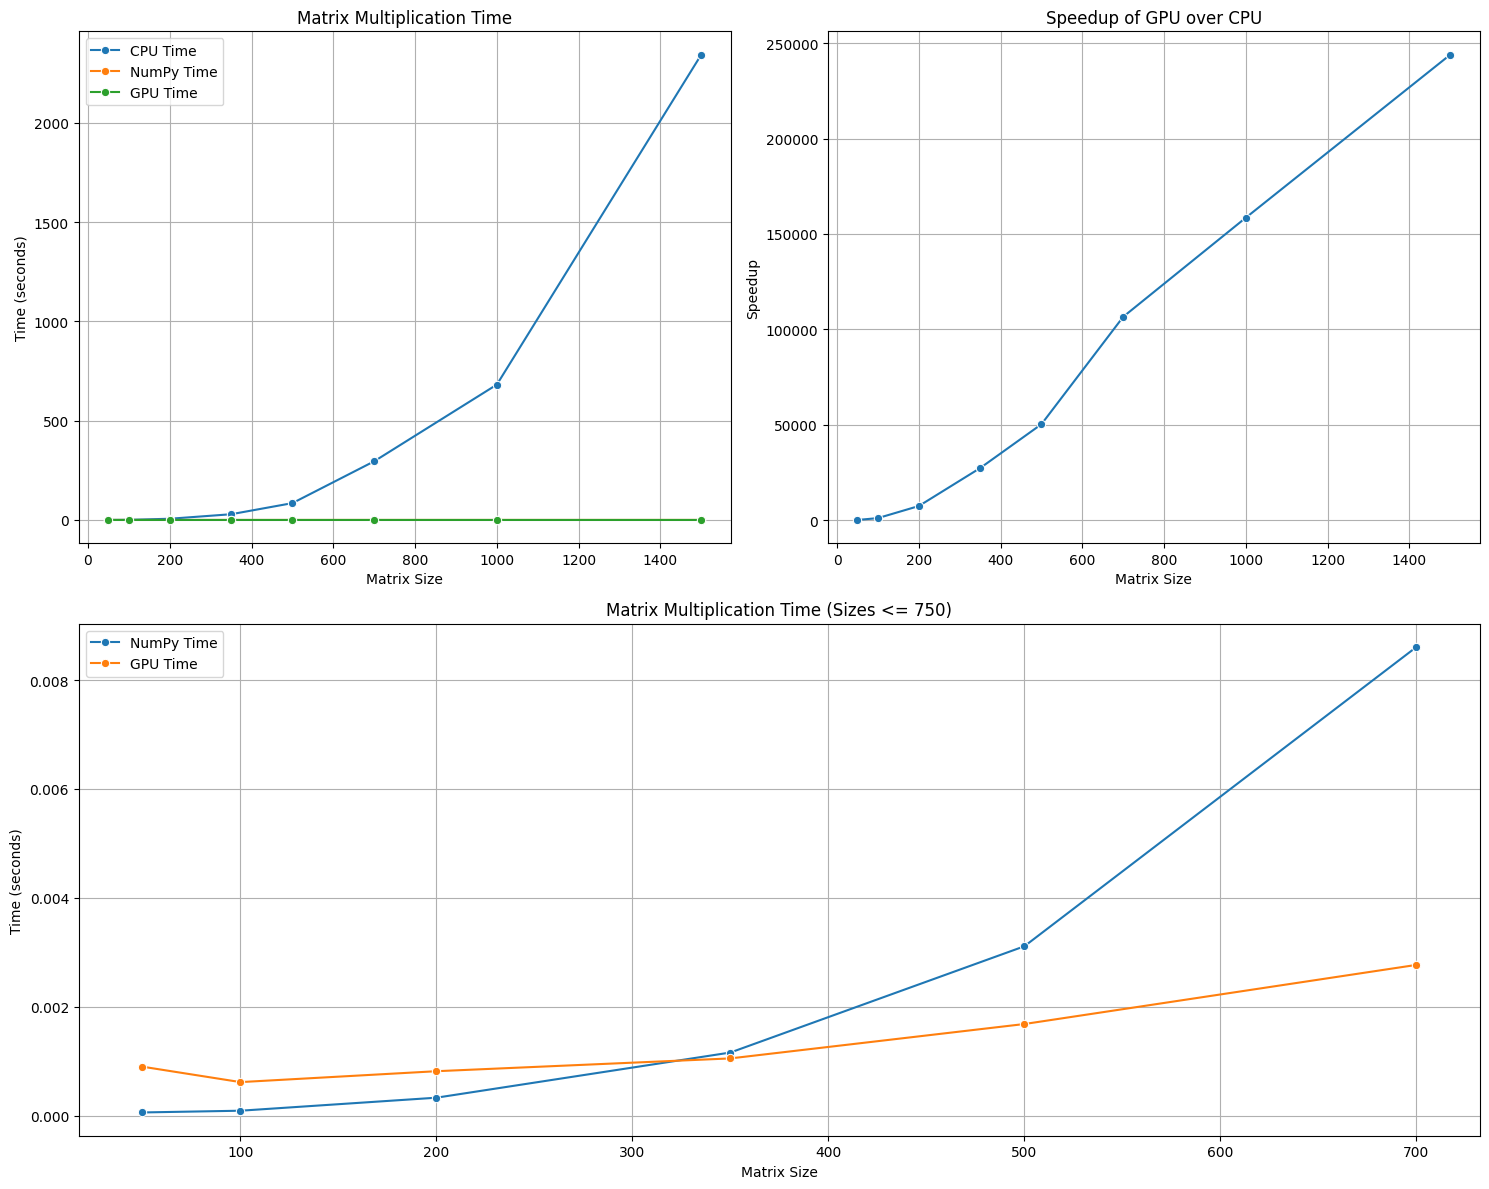

In [18]:
fig = plt.figure(figsize=(15, 12))
gs = gridspec.GridSpec(2, 2, figure=fig)

ax0 = fig.add_subplot(gs[0, 0])
sns.lineplot(x='size', y='cpu_time', data=results, label='CPU Time', marker='o', ax=ax0)
sns.lineplot(x='size', y='numpy_time', data=results, label='NumPy Time', marker='o', ax=ax0)
sns.lineplot(x='size', y='gpu_time', data=results, label='GPU Time', marker='o', ax=ax0)
ax0.set_xlabel('Matrix Size')
ax0.set_ylabel('Time (seconds)')
ax0.set_title('Matrix Multiplication Time')
ax0.legend()
ax0.grid(True)

ax1 = fig.add_subplot(gs[0, 1])
sns.lineplot(x='size', y='speedup', data=results, marker='o', ax=ax1)
ax1.set_xlabel('Matrix Size')
ax1.set_ylabel('Speedup')
ax1.set_title('Speedup of GPU over CPU')
ax1.grid(True)

ax2 = fig.add_subplot(gs[1, :])
filtered_results = results[results['size'] <= 750]
sns.lineplot(x='size', y='numpy_time', data=filtered_results, label='NumPy Time', marker='o', ax=ax2)
sns.lineplot(x='size', y='gpu_time', data=filtered_results, label='GPU Time', marker='o', ax=ax2)
ax2.set_xlabel('Matrix Size')
ax2.set_ylabel('Time (seconds)')
ax2.set_title('Matrix Multiplication Time (Sizes <= 750)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()